# Projet — Analyse et prédiction des prix de vols ✈️
### Fondements de l'IA — jeu de données *EaseMyTrip*

**Objectif.** Le jeu de données contient ~300 000 réservations de vols entre les 6 grandes
métropoles indiennes. La variable à expliquer est le **prix** du billet. On va répondre aux
5 questions de recherche de l'énoncé **et** appliquer les méthodes vues en cours.

**Comment chaque méthode du cours est utilisée :**

| Méthode du cours | Tâche dans ce projet | Type |
|---|---|---|
| **Régression linéaire** | Prédire le **prix** exact d'un billet (variable continue) | Supervisé / régression |
| **Régression logistique** | Classer un vol *cher* / *pas cher* (prix > médiane) | Supervisé / classification |
| **KNN** | Même classification, pour **comparer** avec la régression logistique | Supervisé / classification |
| **PCA (ACP)** | Réduire la dimension après encodage et **visualiser** les vols en 2D | Non supervisé |
| **K-Means** | Regrouper les vols en familles homogènes (méthode du coude) | Non supervisé / clustering |
| **CAH (clustering hiérarchique)** | Confirmer les groupes via un **dendrogramme** | Non supervisé / clustering |

> Toutes ces méthodes sont *utiles* ici : la régression linéaire est la tâche principale
> (cible continue) ; logistique et KNN illustrent et comparent la classification ; PCA + K-Means + CAH
> forment le volet exploratoire non supervisé.


## 0. Importation des bibliothèques

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (r2_score, mean_squared_error, mean_absolute_error,
                             accuracy_score, f1_score, confusion_matrix,
                             classification_report, silhouette_score)
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
RANDOM_STATE = 42
print("Bibliothèques importées.")

Bibliothèques importées.


## 1. Chargement et première exploration

> ⚠️ Adapte simplement `DATA_PATH` à l'emplacement du fichier CSV sur ta machine.

In [2]:
DATA_PATH = "PrixDuVol_Dataset_bruite.csv"   # <-- chemin du fichier

# La 1re colonne du CSV est un index sans nom -> index_col=0
df = pd.read_csv(DATA_PATH, index_col=0)
print("Dimensions :", df.shape)
df.head()

Dimensions : (300153, 11)


,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,NaN,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  str    
 1   flight            300153 non-null  str    
 2   source_city       300153 non-null  str    
 3   departure_time    300153 non-null  str    
 4   stops             300153 non-null  str    
 5   arrival_time      300153 non-null  str    
 6   destination_city  300153 non-null  str    
 7   class             300153 non-null  str    
 8   duration          300149 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 25.2 MB


In [4]:
# Statistiques descriptives (numériques + catégorielles)
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
airline,300153,6,Vistara,127859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
flight,300153,1561,UK-706,3235,NaN,NaN,NaN,NaN,NaN,NaN,NaN
source_city,300153,6,Delhi,61343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
departure_time,300153,6,Morning,71146,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stops,300153,3,one,250863,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_time,300153,6,Night,91538,NaN,NaN,NaN,NaN,NaN,NaN,NaN
destination_city,300153,6,Mumbai,59097,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,300153,2,Economy,206666,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,300149.0,NaN,NaN,NaN,12.22107,7.192012,0.83,6.83,11.25,16.17,49.83
days_left,300153.0,NaN,NaN,NaN,26.004751,13.561004,1.0,15.0,26.0,38.0,49.0


## 2. Nettoyage des données (le jeu est *bruité*)

On vérifie les défauts classiques : **valeurs manquantes**, **doublons**, **incohérences**
dans les catégories et **valeurs aberrantes**.

In [5]:
# 2.1 Valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isna().sum())
print("\nDoublons :", df.duplicated().sum())

Valeurs manquantes par colonne :
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            4
days_left           0
price               0
dtype: int64



Doublons : 0


In [6]:
# 2.2 Cohérence des variables catégorielles (fautes de frappe, catégories en double ?)
cat_check = ['airline','source_city','departure_time','stops',
             'arrival_time','destination_city','class']
for c in cat_check:
    print(f"{c:18s}: {sorted(df[c].unique())}")

airline           : ['AirAsia', 'Air_India', 'GO_FIRST', 'Indigo', 'SpiceJet', 'Vistara']
source_city       : ['Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Kolkata', 'Mumbai']
departure_time    : ['Afternoon', 'Early_Morning', 'Evening', 'Late_Night', 'Morning', 'Night']
stops             : ['one', 'two_or_more', 'zero']
arrival_time      : ['Afternoon', 'Early_Morning', 'Evening', 'Late_Night', 'Morning', 'Night']
destination_city  : ['Bangalore', 'Chennai', 'Delhi', 'Hyderabad', 'Kolkata', 'Mumbai']
class             : ['Business', 'Economy']


In [7]:
# 2.3 Valeurs aberrantes sur les variables numériques
for c in ['duration','days_left','price']:
    s = df[c]
    print(f"{c:10s}  min={s.min():>8}  max={s.max():>8}  "
          f"valeurs<=0={ (s<=0).sum() }")

duration    min=    0.83  max=   49.83  valeurs<=0=0
days_left   min=       1  max=      49  valeurs<=0=0
price       min=    1105  max=  123071  valeurs<=0=0


**Bilan du nettoyage.** Les catégories sont propres (pas de doublons orthographiques) et
aucune valeur numérique négative ou nulle. Le seul *bruit* réel est constitué de quelques
valeurs manquantes dans `duration`. Comme elles sont très peu nombreuses, on supprime ces lignes.
On retire aussi la colonne `flight` (code de vol) : c'est un identifiant à très forte cardinalité,
inutile pour la modélisation.

In [8]:
avant = len(df)
df = df.dropna(subset=['duration']).copy()
df = df.drop(columns=['flight'])
print(f"Lignes supprimées : {avant - len(df)}   ->   jeu final : {df.shape}")

Lignes supprimées : 4   ->   jeu final : (300149, 10)


## 3. Analyse exploratoire — réponses aux questions de recherche

On répond visuellement aux 5 questions de l'énoncé avant toute modélisation.

### (a) Le prix varie-t-il selon la compagnie aérienne ?

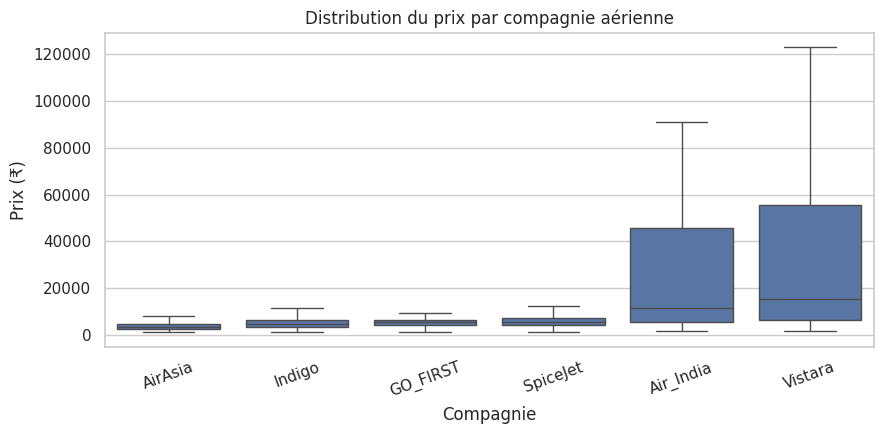

airline
AirAsia       3264.0
Indigo        4453.0
GO_FIRST      5336.0
SpiceJet      5654.0
Air_India    11520.0
Vistara      15543.0
Name: price, dtype: float64


In [9]:
order = df.groupby('airline')['price'].median().sort_values().index
plt.figure(figsize=(9,4.5))
sns.boxplot(data=df, x='airline', y='price', order=order, showfliers=False)
plt.title("Distribution du prix par compagnie aérienne")
plt.xlabel("Compagnie"); plt.ylabel("Prix (₹)"); plt.xticks(rotation=20)
plt.tight_layout(); plt.show()
print(df.groupby('airline')['price'].median().sort_values())

**Réponse (a).** Oui, nettement. *Vistara* et *Air_India* sont bien plus chères (elles
opèrent l'essentiel des vols Business), tandis qu'*AirAsia*, *Indigo*, *GO_FIRST* et *SpiceJet*
sont des compagnies à bas coût.

### (b) Quel est l'effet d'acheter le billet 1–2 jours avant le départ ?

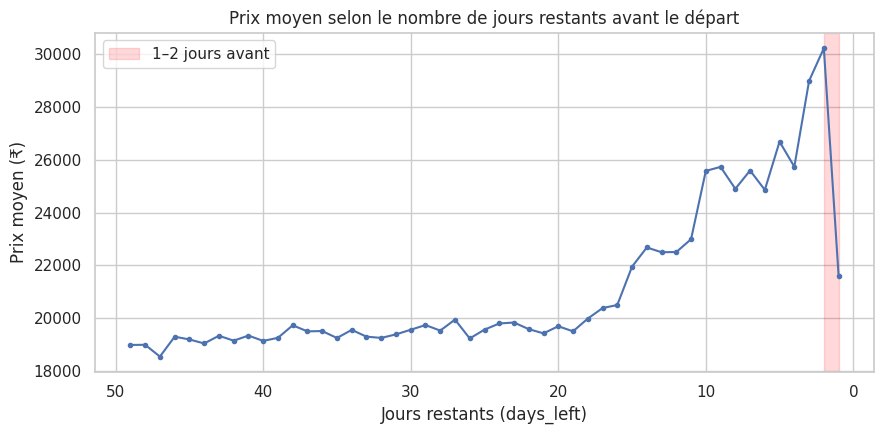

Prix moyen à 1-2 j : 27434
Prix moyen à >2 j  : 20757


In [10]:
moy = df.groupby('days_left')['price'].mean()
plt.figure(figsize=(9,4.5))
plt.plot(moy.index, moy.values, marker='o', ms=3)
plt.axvspan(1, 2, color='red', alpha=0.15, label="1–2 jours avant")
plt.gca().invert_xaxis()  # du plus loin (gauche) au jour du départ (droite)
plt.title("Prix moyen selon le nombre de jours restants avant le départ")
plt.xlabel("Jours restants (days_left)"); plt.ylabel("Prix moyen (₹)")
plt.legend(); plt.tight_layout(); plt.show()
print("Prix moyen à 1-2 j :", round(df[df.days_left<=2].price.mean()))
print("Prix moyen à >2 j  :", round(df[df.days_left> 2].price.mean()))

**Réponse (b).** Acheter à la dernière minute coûte beaucoup plus cher : le prix moyen
explose dans les tout derniers jours (la réservation 1–2 jours avant est nettement au-dessus
de la moyenne générale).

### (c) Le prix dépend-il des heures de départ / d'arrivée ?

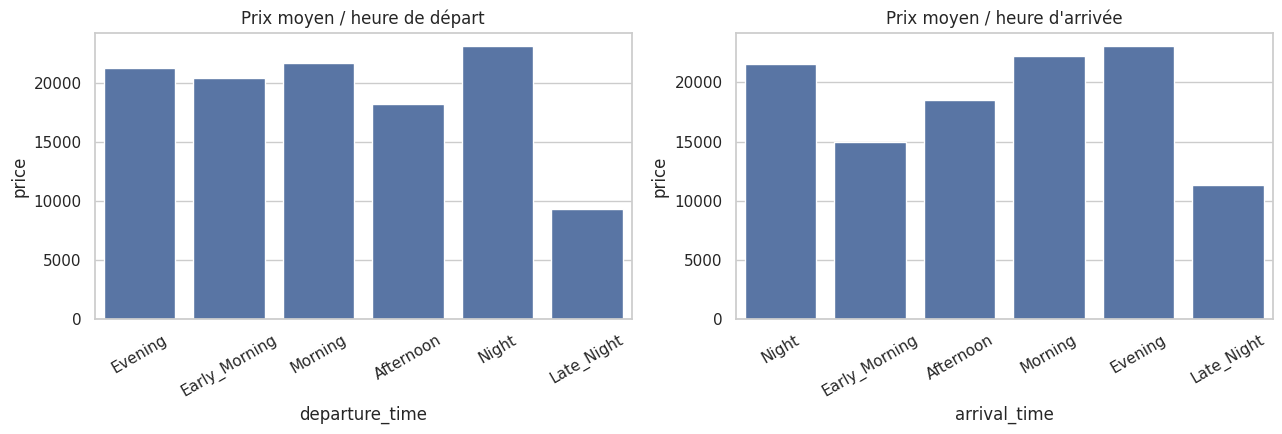

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
sns.barplot(data=df, x='departure_time', y='price', ax=ax[0], errorbar=None)
ax[0].set_title("Prix moyen / heure de départ"); ax[0].tick_params(axis='x', rotation=30)
sns.barplot(data=df, x='arrival_time', y='price', ax=ax[1], errorbar=None)
ax[1].set_title("Prix moyen / heure d'arrivée"); ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

**Réponse (c).** Oui, mais l'effet est modéré : les vols partant/arrivant en pleine nuit
(*Late_Night*) sont en moyenne moins chers, les créneaux *Morning/Evening* un peu plus chers.

### (d) Le prix change-t-il selon la ville source / destination ?

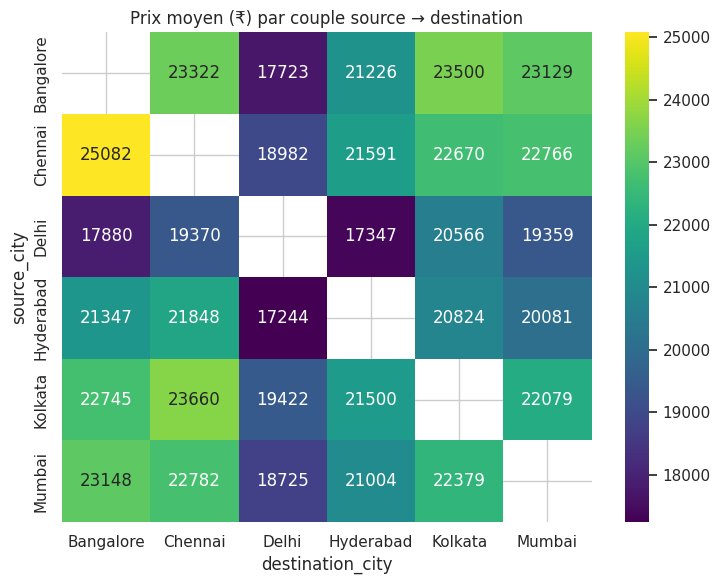

In [12]:
pvt = df.pivot_table(index='source_city', columns='destination_city',
                     values='price', aggfunc='mean')
plt.figure(figsize=(7.5,6))
sns.heatmap(pvt, annot=True, fmt=".0f", cmap="viridis")
plt.title("Prix moyen (₹) par couple source → destination")
plt.tight_layout(); plt.show()

**Réponse (d).** Oui : certaines liaisons (p. ex. impliquant *Kolkata* ou *Chennai*) sont
en moyenne plus chères que d'autres. La ville d'origine et de destination influence le prix.

### (e) Comment le prix varie-t-il entre classe Économie et Affaires ?

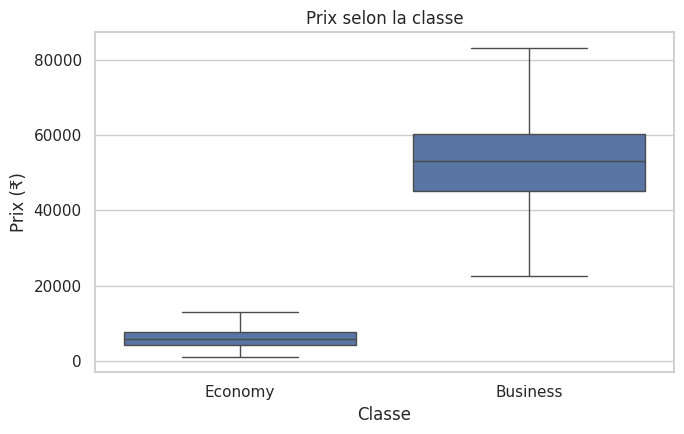

class
Business    52540.0
Economy      6572.0
Name: price, dtype: float64


In [13]:
plt.figure(figsize=(7,4.5))
sns.boxplot(data=df, x='class', y='price', showfliers=False)
plt.title("Prix selon la classe"); plt.xlabel("Classe"); plt.ylabel("Prix (₹)")
plt.tight_layout(); plt.show()
print(df.groupby('class')['price'].mean().round(0))

**Réponse (e).** C'est le facteur le plus important de tous : la classe *Business* coûte
environ **8 fois** plus cher que l'*Économie* en moyenne. On s'attend donc à ce que la classe
soit la variable la plus prédictive du prix.

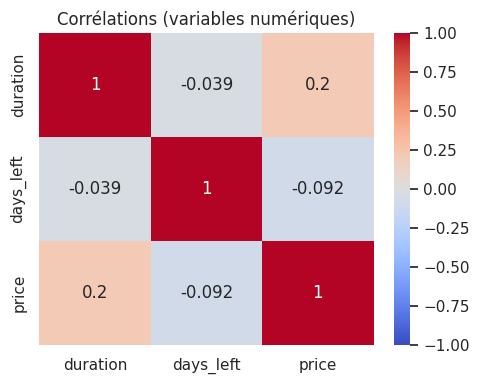

In [14]:
# Corrélation des variables numériques
plt.figure(figsize=(5,4))
sns.heatmap(df[['duration','days_left','price']].corr(),
            annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Corrélations (variables numériques)")
plt.tight_layout(); plt.show()

## 4. Préparation des données pour les modèles

Les modèles ne lisent que des nombres. On définit :
- les variables **catégorielles** → encodage **One-Hot** ;
- les variables **numériques** → **standardisation** (moyenne 0, écart-type 1), indispensable
  pour KNN, PCA et K-Means qui reposent sur des distances.

On utilise un `ColumnTransformer` pour appliquer le bon traitement à chaque colonne,
le tout dans un `Pipeline` (bonne pratique : pas de fuite de données entre train et test).

In [15]:
features_cat = ['airline','source_city','departure_time','stops',
                'arrival_time','destination_city','class']
features_num = ['duration','days_left']

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), features_cat),
    ('num', StandardScaler(), features_num),
])
print("Pré-traitement défini :", len(features_cat), "variables catégorielles +",
      len(features_num), "numériques.")

Pré-traitement défini : 7 variables catégorielles + 2 numériques.


## 5. Régression linéaire — prédire le **prix** (tâche principale)

C'est l'objectif central de l'énoncé : prédire une variable **continue** (le prix).
On évalue avec :
- **R²** : part de variance expliquée (1 = parfait) ;
- **RMSE / MAE** : erreur moyenne en roupies.

In [16]:
X = df[features_cat + features_num]
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE)

reg = Pipeline([('prep', preprocess), ('model', LinearRegression())])
reg.fit(X_train, y_train)
y_pred = reg.predict(X_test)

print(f"R²   = {r2_score(y_test, y_pred):.3f}")
print(f"RMSE = {mean_squared_error(y_test, y_pred)**0.5:,.0f} ₹")
print(f"MAE  = {mean_absolute_error(y_test, y_pred):,.0f} ₹")

R²   = 0.911
RMSE = 6,775 ₹
MAE  = 4,561 ₹


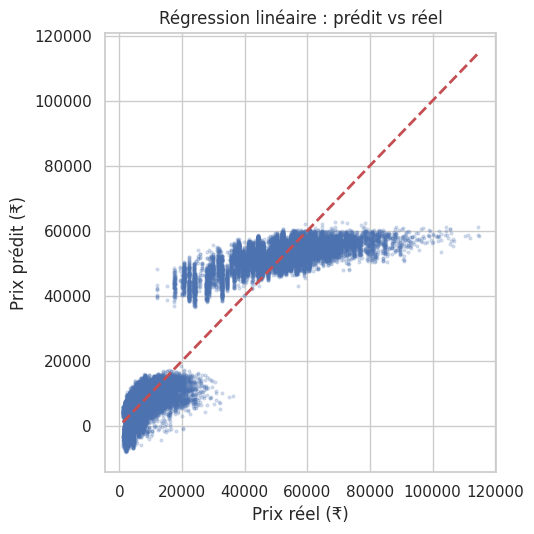

In [17]:
# Prédit vs réel
plt.figure(figsize=(5.5,5.5))
plt.scatter(y_test, y_pred, s=4, alpha=0.2)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--', lw=2)
plt.xlabel("Prix réel (₹)"); plt.ylabel("Prix prédit (₹)")
plt.title("Régression linéaire : prédit vs réel")
plt.tight_layout(); plt.show()

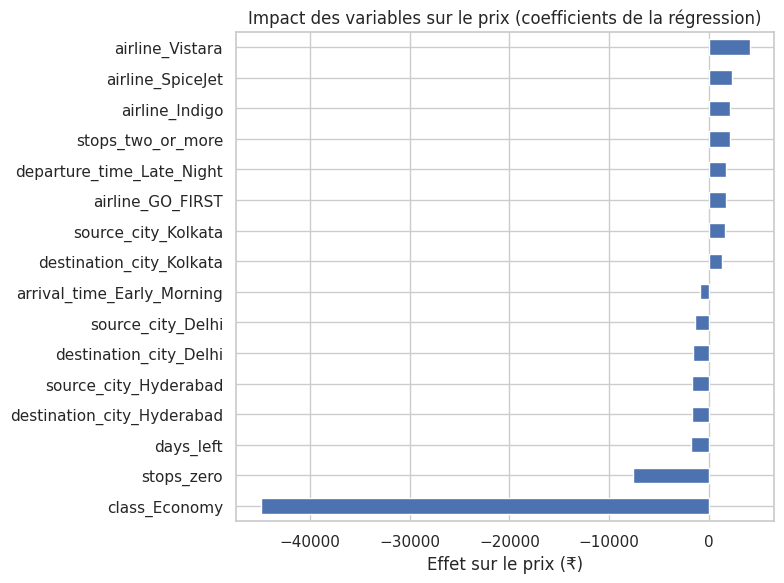

In [18]:
# Variables les plus influentes (coefficients du modèle)
ohe = reg.named_steps['prep'].named_transformers_['cat']
noms = list(ohe.get_feature_names_out(features_cat)) + features_num
coefs = pd.Series(reg.named_steps['model'].coef_, index=noms).sort_values()
plt.figure(figsize=(8,6))
pd.concat([coefs.head(8), coefs.tail(8)]).plot(kind='barh')
plt.title("Impact des variables sur le prix (coefficients de la régression)")
plt.xlabel("Effet sur le prix (₹)"); plt.tight_layout(); plt.show()

**Lecture.** Le R² est élevé (~0,91) : un modèle linéaire simple explique l'essentiel
du prix. Le coefficient le plus fort est de loin `class_Economy` (fortement négatif → être en
Économie fait chuter le prix), ce qui **confirme la question (e)**. La compagnie et le nombre
d'escales pèsent aussi fortement.

## 6. Régression logistique — classer un vol *cher* / *pas cher*

Pour illustrer la **classification**, on crée une cible binaire :
`cher = 1` si le prix dépasse la **médiane**, sinon `0`. La cible est donc parfaitement
équilibrée (50 / 50). On prédit cette étiquette à partir des caractéristiques du vol.

In [19]:
seuil = df['price'].median()
df['cher'] = (df['price'] > seuil).astype(int)
print(f"Seuil (médiane) = {seuil:,.0f} ₹   |   proportion de vols 'chers' = {df['cher'].mean():.2f}")

Xc = df[features_cat + features_num]
yc = df['cher']
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    Xc, yc, test_size=0.20, random_state=RANDOM_STATE, stratify=yc)

logit = Pipeline([('prep', preprocess),
                  ('model', LogisticRegression(max_iter=1000))])
logit.fit(Xc_tr, yc_tr)
yc_pred = logit.predict(Xc_te)
print(f"\nExactitude (accuracy) = {accuracy_score(yc_te, yc_pred):.3f}")
print(f"F1-score              = {f1_score(yc_te, yc_pred):.3f}")
print("\n", classification_report(yc_te, yc_pred, target_names=['pas cher','cher']))

Seuil (médiane) = 7,425 ₹   |   proportion de vols 'chers' = 0.50



Exactitude (accuracy) = 0.910
F1-score              = 0.907

               precision    recall  f1-score   support

    pas cher       0.89      0.93      0.91     30038
        cher       0.93      0.89      0.91     29992

    accuracy                           0.91     60030
   macro avg       0.91      0.91      0.91     60030
weighted avg       0.91      0.91      0.91     60030



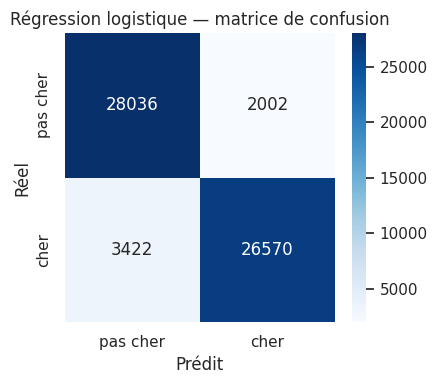

In [20]:
cm = confusion_matrix(yc_te, yc_pred)
plt.figure(figsize=(4.5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['pas cher','cher'], yticklabels=['pas cher','cher'])
plt.xlabel("Prédit"); plt.ylabel("Réel")
plt.title("Régression logistique — matrice de confusion")
plt.tight_layout(); plt.show()

## 7. KNN — même tâche, pour **comparer** les classifieurs

KNN classe un vol selon la classe majoritaire de ses *k* plus proches voisins (en distance).
Il faut **standardiser** (déjà fait dans le pipeline). KNN étant coûteux sur 300 000 points,
on travaille sur un **échantillon** de 30 000 vols (suffisant pour comparer).

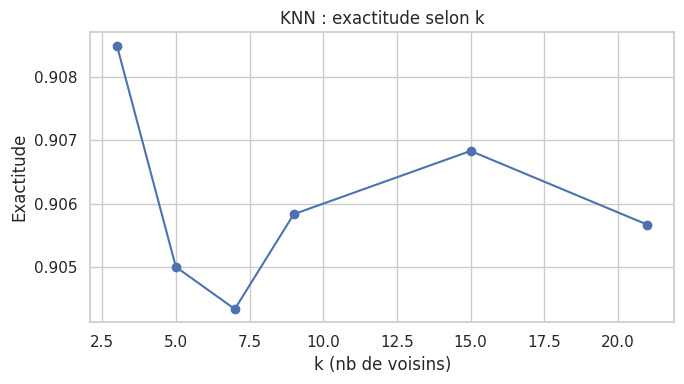

Meilleur k = 3   exactitude = 0.908


In [21]:
ech = df.sample(30000, random_state=RANDOM_STATE)
Xk = ech[features_cat + features_num]; yk = ech['cher']
Xk_tr, Xk_te, yk_tr, yk_te = train_test_split(
    Xk, yk, test_size=0.20, random_state=RANDOM_STATE, stratify=yk)

# Choix de k : on teste plusieurs valeurs
scores = {}
for k in [3, 5, 7, 9, 15, 21]:
    m = Pipeline([('prep', preprocess), ('model', KNeighborsClassifier(k))])
    m.fit(Xk_tr, yk_tr)
    scores[k] = accuracy_score(yk_te, m.predict(Xk_te))
plt.figure(figsize=(7,4))
plt.plot(list(scores), list(scores.values()), marker='o')
plt.title("KNN : exactitude selon k"); plt.xlabel("k (nb de voisins)")
plt.ylabel("Exactitude"); plt.tight_layout(); plt.show()
best_k = max(scores, key=scores.get)
print("Meilleur k =", best_k, "  exactitude =", round(scores[best_k], 3))

In [22]:
knn = Pipeline([('prep', preprocess), ('model', KNeighborsClassifier(best_k))])
knn.fit(Xk_tr, yk_tr)
yk_pred = knn.predict(Xk_te)
print(f"KNN (k={best_k}) — exactitude = {accuracy_score(yk_te, yk_pred):.3f} | "
      f"F1 = {f1_score(yk_te, yk_pred):.3f}")

print("\n--- Comparaison des deux classifieurs ---")
print(f"Régression logistique : {accuracy_score(yc_te, yc_pred):.3f}")
print(f"KNN (k={best_k})           : {accuracy_score(yk_te, yk_pred):.3f}")

KNN (k=3) — exactitude = 0.908 | F1 = 0.907

--- Comparaison des deux classifieurs ---
Régression logistique : 0.910
KNN (k=3)           : 0.908


**Comparaison.** Les deux modèles atteignent ~0,90 d'exactitude. La régression logistique
est ici aussi performante que KNN, tout en étant beaucoup plus rapide et **interprétable**
(on lit directement l'effet de chaque variable). Sur un grand jeu de données, on préférera
donc la régression logistique.

## 8. PCA (ACP) — réduction de dimension et visualisation

Après encodage One-Hot, on a beaucoup de colonnes. La **PCA** projette ces dimensions sur
quelques **composantes principales** qui capturent le maximum de variance, ce qui permet de
**visualiser** les vols en 2D. On travaille sur l'échantillon standardisé.

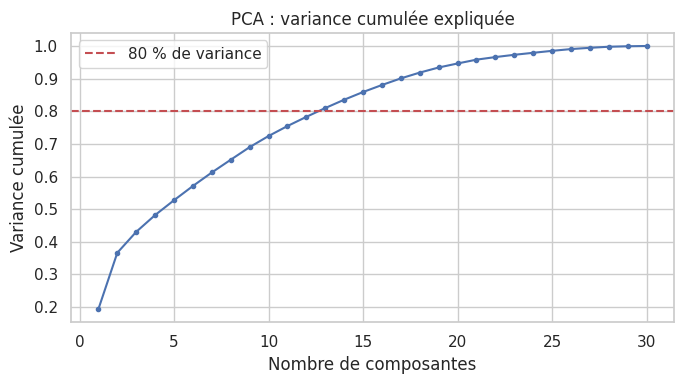

Variance expliquée par les 2 premières composantes : 36.6%


In [23]:
X_enc = preprocess.fit_transform(ech[features_cat + features_num])
X_enc = X_enc.toarray() if hasattr(X_enc, "toarray") else X_enc

pca_full = PCA().fit(X_enc)
var = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(7,4))
plt.plot(range(1, len(var)+1), var, marker='o', ms=3)
plt.axhline(0.8, color='r', ls='--', label="80 % de variance")
plt.title("PCA : variance cumulée expliquée")
plt.xlabel("Nombre de composantes"); plt.ylabel("Variance cumulée")
plt.legend(); plt.tight_layout(); plt.show()
print(f"Variance expliquée par les 2 premières composantes : "
      f"{pca_full.explained_variance_ratio_[:2].sum():.1%}")

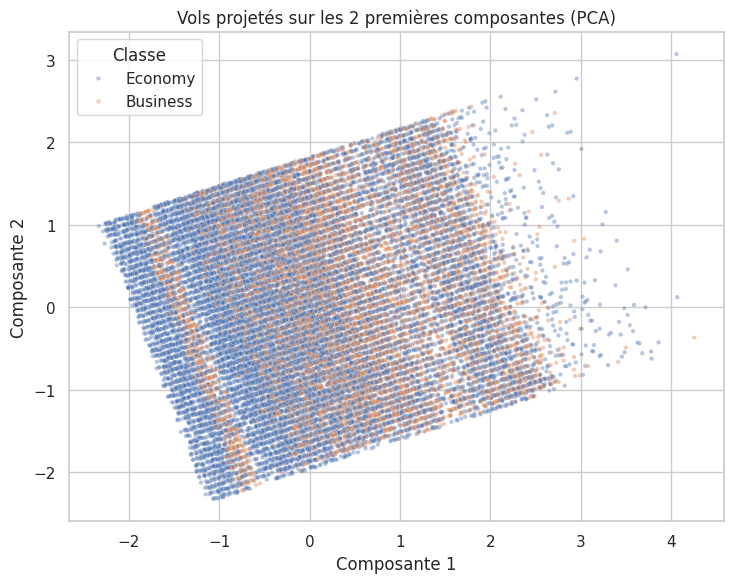

In [24]:
coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_enc)
plt.figure(figsize=(7.5,6))
sns.scatterplot(x=coords[:,0], y=coords[:,1],
                hue=ech['class'].values, s=10, alpha=0.4)
plt.title("Vols projetés sur les 2 premières composantes (PCA)")
plt.xlabel("Composante 1"); plt.ylabel("Composante 2")
plt.legend(title="Classe"); plt.tight_layout(); plt.show()

**Lecture.** La projection 2D sépare déjà visuellement les vols *Business* des vols
*Économie* : la structure dominante des données est bien la **classe**. La PCA confirme donc,
de façon non supervisée, ce qu'on a vu en (e).

## 9. K-Means — regrouper les vols en familles

On cherche des groupes naturels de vols. On choisit le nombre de clusters *k* avec la
**méthode du coude** (inertie) et le **score de silhouette**, puis on visualise les groupes
dans le plan PCA.

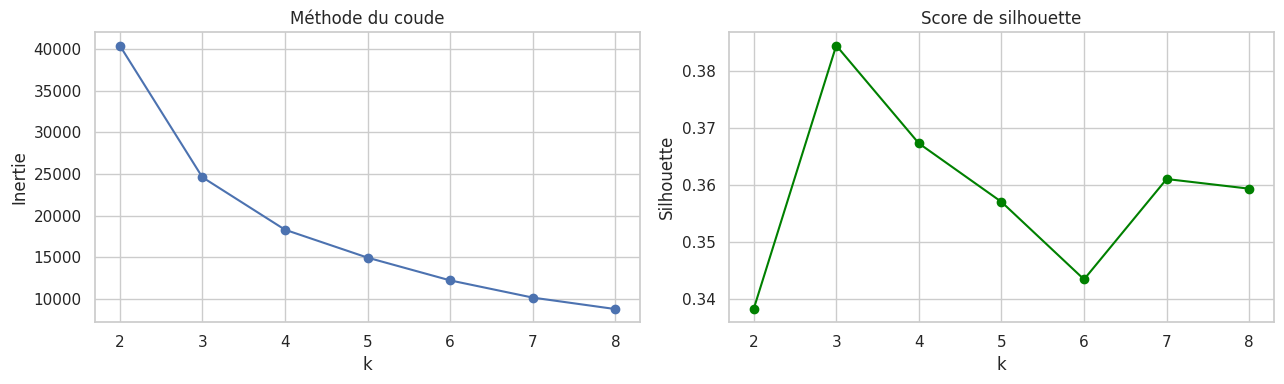

In [25]:
inerties, silhouettes = [], []
Ks = range(2, 9)
for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(coords)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(coords, km.labels_, sample_size=5000,
                                         random_state=RANDOM_STATE))
fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].plot(list(Ks), inerties, marker='o'); ax[0].set_title("Méthode du coude")
ax[0].set_xlabel("k"); ax[0].set_ylabel("Inertie")
ax[1].plot(list(Ks), silhouettes, marker='o', color='green')
ax[1].set_title("Score de silhouette"); ax[1].set_xlabel("k"); ax[1].set_ylabel("Silhouette")
plt.tight_layout(); plt.show()

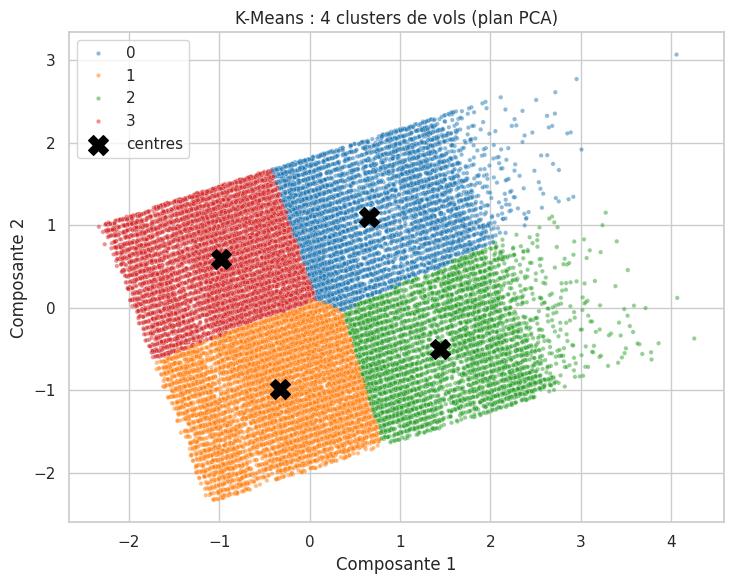

In [26]:
k_opt = 4   # choisi d'après le coude
km = KMeans(n_clusters=k_opt, n_init=10, random_state=RANDOM_STATE).fit(coords)
ech = ech.copy(); ech['cluster'] = km.labels_

plt.figure(figsize=(7.5,6))
sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=km.labels_,
                palette='tab10', s=10, alpha=0.5)
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],
            c='black', s=200, marker='X', label='centres')
plt.title(f"K-Means : {k_opt} clusters de vols (plan PCA)")
plt.xlabel("Composante 1"); plt.ylabel("Composante 2")
plt.legend(); plt.tight_layout(); plt.show()

In [27]:
# Interprétation : profil moyen de chaque cluster
profil = ech.groupby('cluster').agg(
    prix_moyen=('price','mean'),
    duree_moyenne=('duration','mean'),
    jours_restants=('days_left','mean'),
    pct_business=('class', lambda s: (s=='Business').mean()*100),
    nb_vols=('price','size')).round(1)
profil

,prix_moyen,duree_moyenne,jours_restants,pct_business,nb_vols
cluster,,,,,
0,26042.5,18.9,37.1,42.6,6202
1,18644.9,7.9,14.8,24.9,9654
2,29234.4,20.5,13.1,42.6,5299
3,14763.8,7.3,37.9,22.7,8845


**Lecture.** Les clusters correspondent à des **profils de vols** interprétables : par
exemple un groupe « Business cher », un groupe « Économie court-courrier bon marché », etc.
(voir le tableau : prix moyen et % de Business très contrastés selon le cluster).

## 10. CAH — clustering hiérarchique (dendrogramme)

La **Classification Ascendante Hiérarchique** fusionne progressivement les points les plus
proches. Son coût mémoire est en O(n²) : on l'applique donc sur un **petit échantillon**
(800 vols) pour pouvoir tracer le **dendrogramme** et confirmer le nombre de groupes.

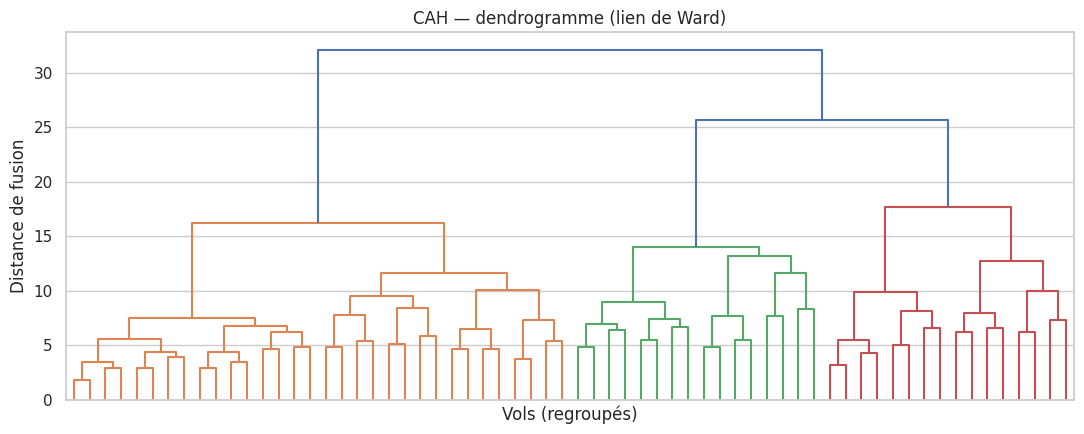

In [28]:
petit = ech.sample(800, random_state=RANDOM_STATE)
X_petit = preprocess.transform(petit[features_cat + features_num])
X_petit = X_petit.toarray() if hasattr(X_petit, "toarray") else X_petit

Z = linkage(X_petit, method='ward')
plt.figure(figsize=(11,4.5))
dendrogram(Z, truncate_mode='level', p=5, no_labels=True, color_threshold=0.7*max(Z[:,2]))
plt.title("CAH — dendrogramme (lien de Ward)")
plt.xlabel("Vols (regroupés)"); plt.ylabel("Distance de fusion")
plt.tight_layout(); plt.show()

In [29]:
# Couper l'arbre en 4 groupes et comparer la composition
petit = petit.copy()
petit['cah'] = fcluster(Z, t=4, criterion='maxclust')
print("Répartition Business/Économie par groupe CAH :")
print(pd.crosstab(petit['cah'], petit['class']))

Répartition Business/Économie par groupe CAH :
class  Business  Economy
cah                     
1            90      146
2            80      214
3            29       60
4            49      132


**Lecture.** Le dendrogramme montre une coupure naturelle en quelques grands groupes, et
ces groupes séparent là encore Business et Économie : K-Means et CAH **convergent** vers la
même structure. C'est rassurant : la structure trouvée n'est pas un artefact d'un seul
algorithme.

## 11. Synthèse / Conclusion

**Réponses aux questions de recherche**
- **(a)** Le prix dépend fortement de la **compagnie** (Vistara/Air_India >> low-cost).
- **(b)** Acheter **1–2 jours avant** le départ est nettement plus cher.
- **(c)** L'**heure** de départ/arrivée a un effet modéré (les vols de nuit sont moins chers).
- **(d)** La **liaison** (source → destination) influence le prix.
- **(e)** La **classe** est le facteur dominant : Business ≈ 8× le prix de l'Économie.

**Ce que chaque méthode a apporté**
- *Régression linéaire* : prédit le prix avec **R² ≈ 0,91** ; ses coefficients confirment que la
  classe et la compagnie dominent.
- *Régression logistique* & *KNN* : classent « cher / pas cher » à **~90 %** ; la logistique est
  aussi bonne mais plus rapide et interprétable.
- *PCA* : 2 composantes suffisent à visualiser la séparation Business/Économie.
- *K-Means* & *CAH* : identifient ~4 familles de vols cohérentes et **convergentes**.

**Conclusion.** Le prix d'un billet est très prévisible à partir de variables simples,
principalement la **classe**, la **compagnie**, le **nombre d'escales** et le **délai de
réservation**. Un modèle linéaire suffit à capturer l'essentiel.
